# 2. Signal check

Before scoring anything, three questions:

1. **Is the signal usable at all?**
2. **Does it need a notch filter?** — mains interference at 50 or 60 Hz.
3. **Where should the analysis start and end?** — recordings often begin and end
   with the animal being handled, or a connector working loose.

This notebook shows these problems on a synthetic recording built to have them, and measures what fixing
them is worth.

## 1. Setup

In [1]:
import os

for _var in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "BLIS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import matplotlib.pyplot as plt

import nyx

## 2. A recording with both problems

`demo_messy_recording()` is the clean demo signal plus 50 Hz mains interference
(with harmonics, as real pickup always has) and ten minutes of saturated signal
at each end.

Replace this with your own file when you have one:

```python
recording = nyx.read_recording(r"...\A31_D04.edf", eeg_channel=0, emg_channel=1)
```

In [2]:
recording, truth = nyx.demo_messy_recording()
print(recording.describe())

c:\Users\letizias\.conda\envs\nyx_dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


demo: 5200.0s at 128 Hz
  EEG channel: EEG
  EMG channel: EMG


## 3. The check

`check_signals` previews the **start and the end** of the recording — the two
places artefacts live — as traces with their spectrograms underneath.

For a long recording it previews 10000 s at each end rather than drawing the
whole thing; `preview=` changes that, and `preview=None` shows everything.

In [3]:
check = nyx.check_signals(recording)
print(check.summary())

demo: 5200s at 128 Hz
  previewed: full 0-5200s
  line-noise check (peak above local baseline):
    EEG_50Hz        +21.0 dB  <- consider a notch
    EEG_60Hz         +0.3 dB
    EMG_50Hz        +20.6 dB  <- consider a notch
    EMG_60Hz         +0.2 dB
  suggestion: set "notch": 50 in the EEG/EMG params.


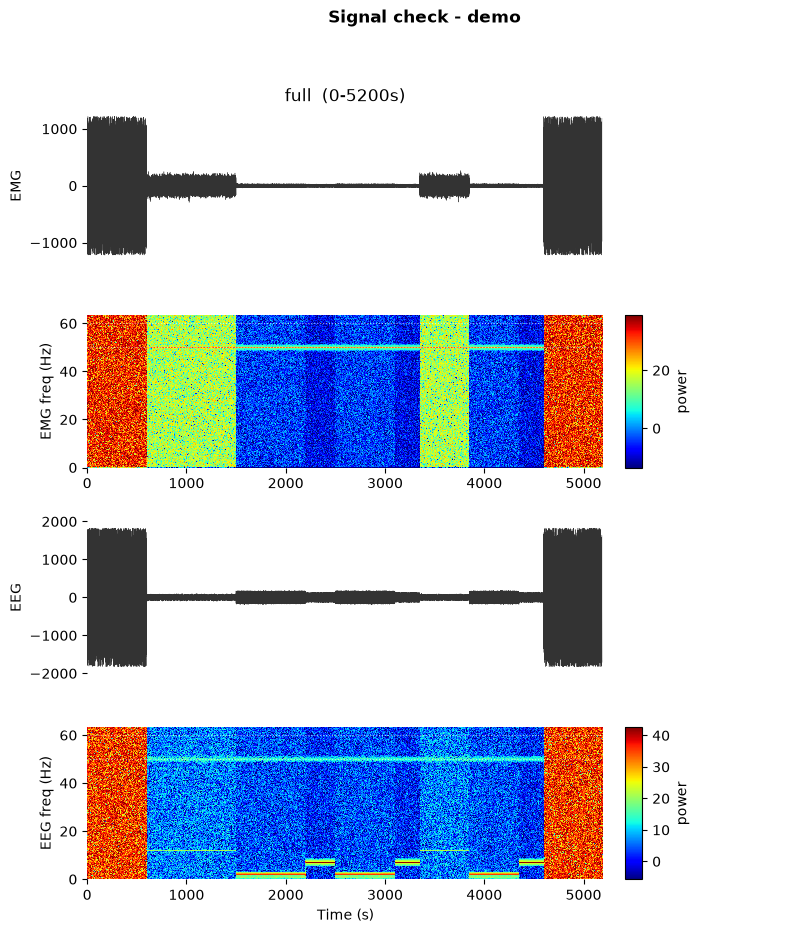

In [4]:
check.plot()
plt.show()

The line-noise score is the height of the peak at 50 (or 60) Hz above the
median of the bands either side of it, in dB. Above 3 dB is worth notching.
`suggested_notch()` returns `50`, `60` or `None`.

In [5]:
print("line-noise scores (dB above local baseline):")
for name, value in sorted(check.line_noise.items()):
    print(f"  {name:<14} {value:+6.1f}")

print()
print("suggested notch:", check.suggested_notch())

line-noise scores (dB above local baseline):
  EEG_50Hz        +21.0
  EEG_60Hz         +0.3
  EMG_50Hz        +20.6
  EMG_60Hz         +0.2

suggested notch: 50.0


### Previewing what the notch would do

`notch=` recomputes the preview with the filter applied, **without changing the
recording** — so you can see whether it cleans things up before committing to it.

In [6]:
previewed = nyx.check_signals(recording, notch=check.suggested_notch())
print(previewed.summary())

demo: 5200s at 128 Hz
  previewed: full 0-5200s
  notch applied at 50 Hz
  line-noise check (peak above local baseline):
    EEG_50Hz         -1.1 dB
    EEG_60Hz         +0.5 dB
    EMG_50Hz         -1.0 dB
    EMG_60Hz         +0.3 dB
  suggestion: no notch needed.


c:\Users\letizias\.conda\envs\nyx_dev\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (122 samples) is more than 20% of the global chunk size 128 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(


The score goes from about +21 dB to slightly **below** zero — the notch cuts the
line to a little under the level of the bands either side of it. That is a
narrow filter doing its job: the line is gone and the neighbouring real signal
is still there.

## 4. Where to start and stop

The saturated stretches are obvious in the traces above. Set the window inside
them.

In [7]:
WINDOW = (600, recording.duration - 600)
print(f"analysing {WINDOW[0]:g}-{WINDOW[1]:g}s of {recording.duration:.0f}s")

analysing 600-4600s of 5200s


## 5. What fixing them is worth

Three runs on the same recording: as-is, and with each fix.

In [8]:
params = nyx.demo_params()

fixed = {**params}
fixed["EEG"] = {**params["EEG"], "notch": 50}
fixed["EMG"] = {**params["EMG"], "notch": 50}

runs = {
    "nothing fixed":     (params, None),
    "notch only":        (fixed, None),
    "notch + trimmed":   (fixed, WINDOW),
}

results = {}
for label, (these_params, window) in runs.items():
    result = nyx.score_recording(recording, these_params, window=window,
                                 reference=truth, verbose=False)
    results[label] = result
    print(f"{label:<18} MF1 {result.agreement.mf1:.3f}")

nothing fixed      MF1 0.897
notch only         MF1 0.897


c:\Users\letizias\.conda\envs\nyx_dev\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (122 samples) is more than 20% of the global chunk size 128 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(
c:\Users\letizias\.conda\envs\nyx_dev\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (122 samples) is more than 20% of the global chunk size 128 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(


notch + trimmed    MF1 0.995


Trimming is what matters here. Saturated signal is enormous
compared with real EEG, so it dominates the spectral PCA and pulls the
components towards describing the artefact rather than the difference between
sleep stages.

The notch changes **nothing at all** on this recording: the demo params analyse
0.5–30 Hz (EEG) and 30–60 Hz (EMG), and 50 Hz interference sits at the very top
of the EMG band and outside the EEG band entirely. There is almost nothing for
it to fix.

That is a property of *these* params. It is always worth checking with real signals

## 6. The overview figure

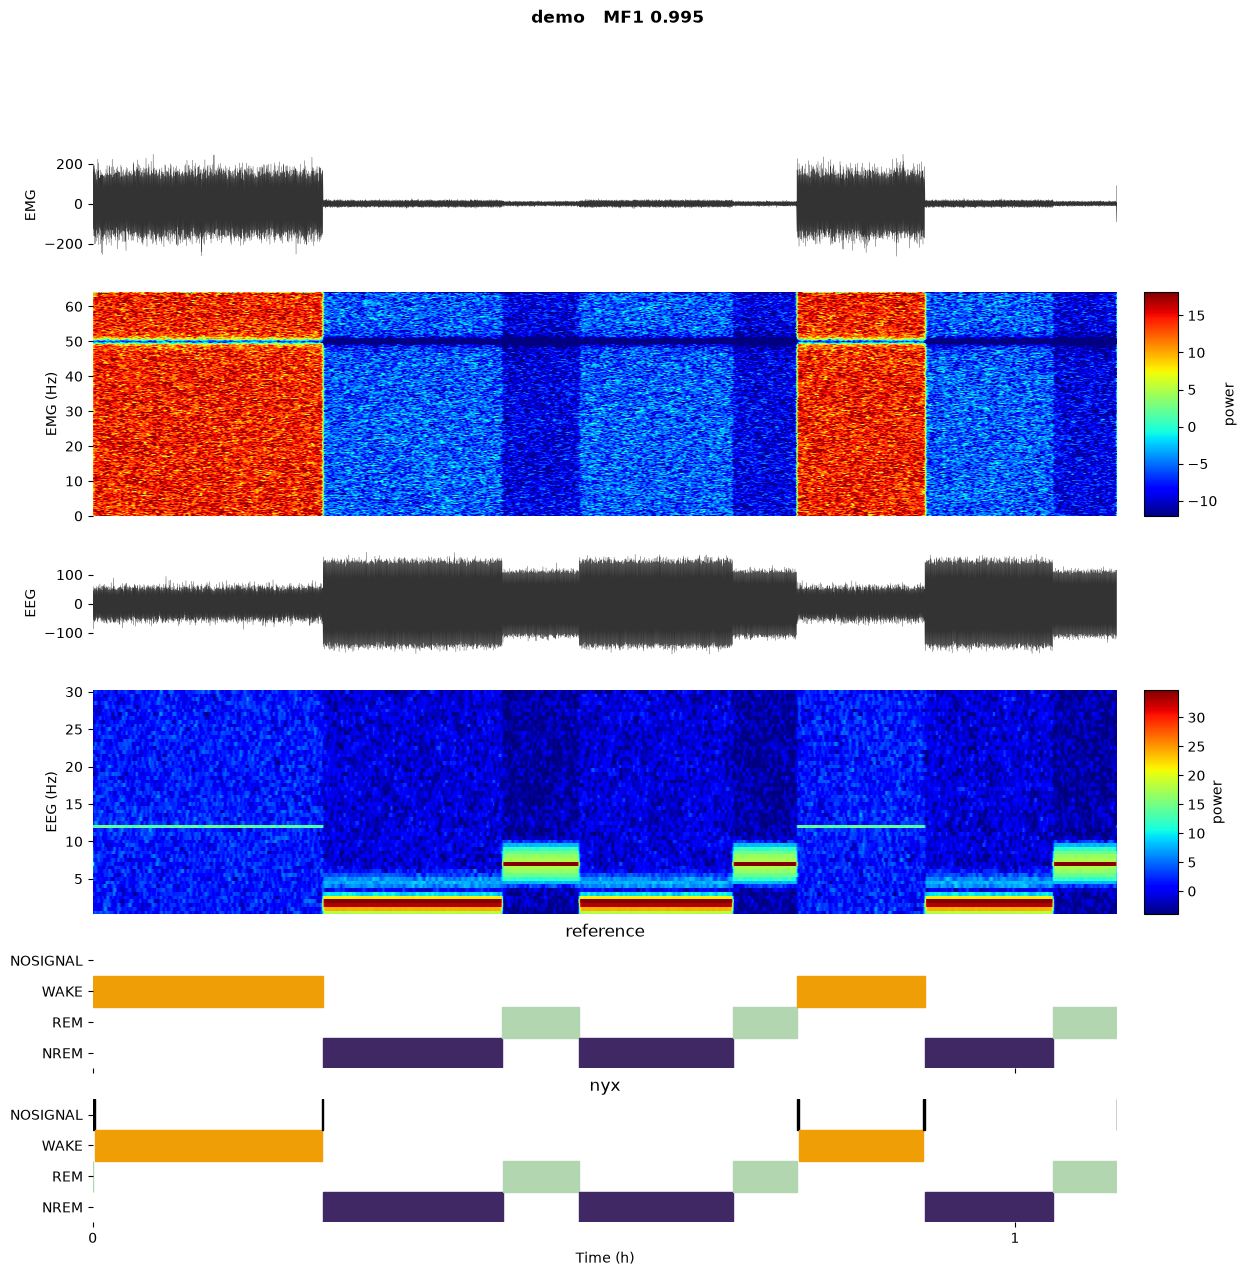

In [9]:
nyx.plot_scoring_overview(results["notch + trimmed"])
plt.show()

## 7. Writing it down

Put the notch in your params file so it applies to every recording from that rig:

```jsonc
"EEG": { ..., "notch": 50 },
"EMG": { ..., "notch": 50 }
```

Preprocessing runs through spikeinterface and is **lazy** — a 24 h recording is
not copied to filter it — and happens **once, up front**, so the signal check and
the scoring see exactly the same signal.

Anything in `spikeinterface.preprocessing` can be named directly when you need
more than a notch:

```jsonc
"EEG": {
  "preprocess": [
    {"notch_filter":    {"freq": 50, "q": 30}},
    {"bandpass_filter": {"freq_min": 0.5, "freq_max": 45}},
    {"resample":        {"resample_rate": 250}}
  ]
}
```

The order is the order you write, and it matters — notching before resampling is
not the same as after. Because it lives in the params it lands in `run.json` and
replays.